In [31]:
import json
from typing import List, Dict, Any, Optional
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes import Axes
from matplotlib.figure import Figure

def load_data(input_file: Optional[str]) -> pd.DataFrame:
    data: List[Dict[str, Any]] = []
    
    # Select source
    if input_file and input_file != "-":
        with open(input_file, 'r') as f:
            lines = f.readlines()

    for line in lines:
        line = line.strip()
        if not line:
            continue
        try:
            entry = json.loads(line)
            data.append(entry)
        except json.JSONDecodeError:
            continue

    df = pd.DataFrame(data)
    if 'duration_ms' in df.columns:
        df['duration_ms'] = pd.to_numeric(df['duration_ms'], errors='coerce')
    if 'size' in df.columns:
        df['size'] = pd.to_numeric(df['size'], errors='coerce')
    if 'attempted_programs' in df.columns:
        df['attempted_programs'] = pd.to_numeric(df['attempted_programs'], errors='coerce')
    if 'success' in df.columns:
        df['success'] = df['success'].astype(bool)

    return df

In [32]:
def plot_duration_distributions(df: pd.DataFrame) -> None:
    unique_sizes: List[int] = sorted(df['size'].unique().tolist())
    n_sizes = len(unique_sizes)
    
    if n_sizes == 0:
        return

    fig, axes = plt.subplots(nrows=1, ncols=n_sizes, figsize=(6 * n_sizes, 5), sharey=False) # type: ignore
    
    ax_list: List[Axes] = [axes] if n_sizes == 1 else list(axes) # type: ignore
    df['duration_s'] = df['duration_ms']/1000

    for i, size in enumerate(unique_sizes):
        ax = ax_list[i]
        subset = df[df['size'] == size]
        
        success_data = subset[subset['success'] == True]['duration_s']
        fail_data = subset[subset['success'] == False]['duration_s']

        if not fail_data.empty:
            weights = [1.0 / len(fail_data)] * len(fail_data)
            ax.hist(
                fail_data, 
                bins=20, 
                alpha=0.6, 
                color='red', 
                label=f'Failure (n={len(fail_data)})',
                edgecolor='black',
                weights=weights
            )

        if not success_data.empty:
            weights = [1.0 / len(success_data)] * len(success_data)
            ax.hist(
                success_data, 
                bins=10, 
                alpha=0.6, 
                color='green', 
                label=f'Success (n={len(success_data)})',
                edgecolor='black',
                weights=weights
            )

        ax.set_title(f"Duration Distribution (Size {size})")
        ax.set_xlabel("Duration (s)")
        ax.set_ylabel("Frequency")
        ax.legend()
        ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

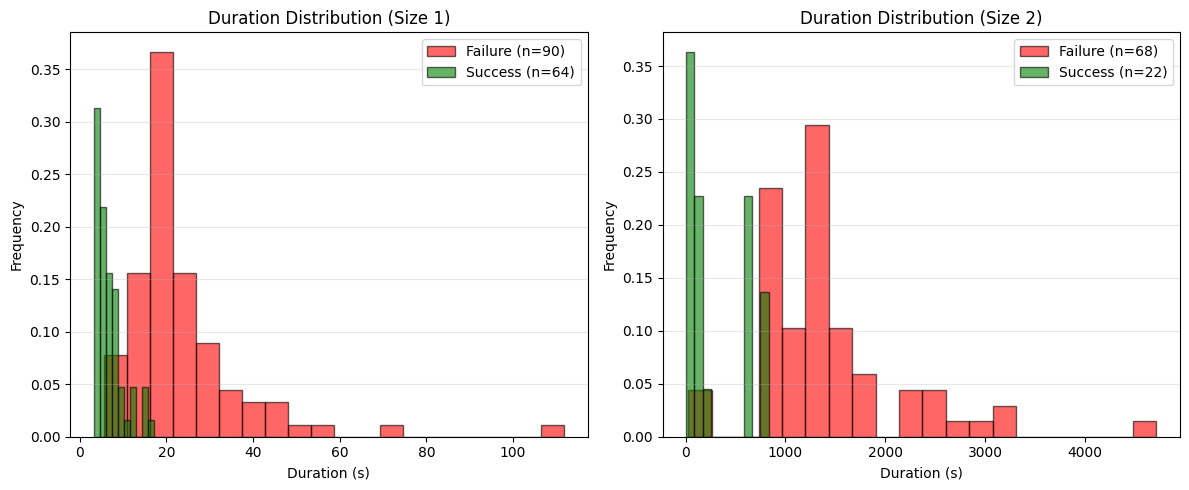

In [33]:
lowerings=load_data("arith_trunc_ref.jsonl")
plot_duration_distributions(lowerings)

In [34]:
from xdsl.context import Context
from xdsl.parser import Parser
from xdsl.printer import Printer
from xdsl.ir import Operation
from xdsl.dialects.builtin import ModuleOp
from xdsl.dialects.func import FuncOp, ReturnOp
from xdsl.traits import IsTerminator
from xdsl_smt.dialects import get_all_dialects
from io import StringIO
import re

def get_root_operation(module: ModuleOp) -> Operation:
    target_block = module.body.blocks[0]
    for op in module.body.blocks[0].ops:
        if isinstance(op, FuncOp):
            target_block = op.body.blocks[0]
            break

    ops = [o for o in target_block.ops if not (o.has_trait(IsTerminator) or isinstance(o, ReturnOp))]
    if not ops:
        raise ValueError("No target operation found.")
    
    return ops[-1]

def get_instruction_label(op: Operation) -> str:
    io = StringIO()
    Printer(stream=io, print_generic_format=False).print_op(op)
    custom_str = io.getvalue().strip()
    
    # Regex to strip SSA assignments capture the op name
    match = re.search(r'(?:%[\w\d_]+\s*=\s*)?([a-zA-Z0-9_.]+)(.*)', custom_str)
    
    if not match:
        op_name = op.name
        rest = ""
    else:
        op_name = match.group(1)
        rest = match.group(2).strip()
        
    label = op_name
    
    if op_name == "arith.cmpi":
        pred_match = re.match(r'([a-zA-Z_]+)', rest)
        if pred_match:
            predicate = pred_match.group(1)
            label = f"{op_name} {predicate}"

    op_type_str = ""
    if len(op.operands) > 0:
        op_type_str = str(op.operands[0].type)
    elif len(op.results) > 0:
        op_type_str = str(op.results[0].type)
        
    op_type_str = op_type_str.replace("!", "")
    
    if op_type_str:
        label = f"{label} {op_type_str}"
        
    return label

def parse_synthesis_logs(input_file: Optional[str]) -> pd.DataFrame:
    ctx = Context()
    ctx.allow_unregistered = True
    for name, factory in get_all_dialects().items():
        ctx.register_dialect(name, factory)

    f = open(input_file, 'r')

    records = []
    
    for line in f:
        line = line.strip()
        if not line:
            continue
            
        data = json.loads(line)

        if data.get("success"):
            module = Parser(ctx, data["input"]).parse_module()
            root_op = get_root_operation(module)
            label = get_instruction_label(root_op)

            size = data.get("size", "unknown")
            full_label = f"{label} (size: {size})"
            
            records.append({
                "instruction": full_label,
                "duration_ms": data.get("duration_ms", 0)
            })
            

    f.close()

    return pd.DataFrame(records)

def plot_horizontal_bar(df: pd.DataFrame):
    if df.empty:
        print("No successful data to plot.")
        return

    df_plot = df.groupby('instruction')['duration_ms'].mean().reset_index()
    
    df_plot = df_plot.sort_values(by='duration_ms', ascending=True)

    fig_height = max(4.0, len(df_plot) * 0.10)
    plt.figure(figsize=(10, fig_height))
    
    plt.barh(
        df_plot['instruction'], 
        df_plot['duration_ms'], 
        color='mediumseagreen', 
        edgecolor='black',
        alpha=0.8
    )
    plt.xscale('log')

    plt.yticks(fontsize=8)

    plt.xlabel('Synthesis Time (ms) - Log Scale', fontsize=12)
    plt.ylabel('Instruction', fontsize=12)

    
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()


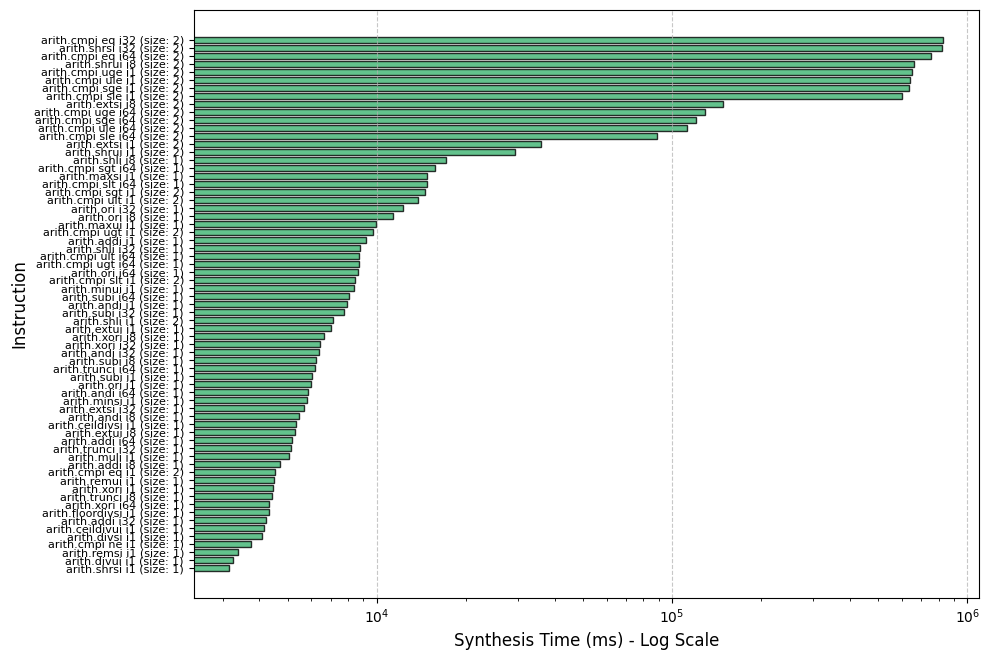

In [35]:

df = parse_synthesis_logs("arith_trunc_ref.jsonl")
plot_horizontal_bar(df)

In [43]:

def parse_synthesis_logs_all(input_file: Optional[str]) -> pd.DataFrame:
    ctx = Context()
    ctx.allow_unregistered = True
    for name, factory in get_all_dialects().items():
        ctx.register_dialect(name, factory)

    records = []
    
    with open(input_file, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
                
            try:
                data = json.loads(line)
            except json.JSONDecodeError:
                continue

            input_mlir = data.get("input")
            if not input_mlir:
                continue
            
            # Parse the source MLIR to get the instruction label
            module = Parser(ctx, input_mlir).parse_module()
            root_op = get_root_operation(module)
            label = get_instruction_label(root_op)

            size = data.get("size", "unknown")
            full_label = f"{label} (size: {size})"
            
            duration_ms = float(data.get("duration_ms", 0))
            # Default to 1 to avoid division by zero in case of corrupted data
            attempted_programs = max(1, int(data.get("attempted_programs", 1)))
            
            records.append({
                "instruction": full_label,
                "duration_ms": duration_ms,
                "attempted_programs": attempted_programs,
                "duration_per_program": duration_ms / attempted_programs,
                "success": data.get("success", False)
            })
            
    return pd.DataFrame(records)


def plot_duration_per_program_bar(df: pd.DataFrame):
    if df.empty:
        return

    df_filtered = df[~df['instruction'].str.contains(r'\b(i1|i8)\b', regex=True)]
    df_filtered = df_filtered[df_filtered['attempted_programs'] >= 20]
    df_filtered['base_inst'] = df_filtered['instruction'].str.extract(r'(.*?)\s*\(size:')[0]
    df_filtered['parsed_size'] = df_filtered['instruction'].str.extract(r'size:\s*(\d+)')[0].astype(float)
    max_sizes = df_filtered.groupby('base_inst')['parsed_size'].transform('max')
    df_filtered = df_filtered[df_filtered['parsed_size'] == max_sizes]

    if df_filtered.empty:
        return

    df_plot = df_filtered.groupby('instruction')['duration_per_program'].mean().reset_index()
    df_plot = df_plot.sort_values(by='duration_per_program', ascending=True)

    fig_height = max(4.0, len(df_plot) * 0.10)
    plt.figure(figsize=(10, fig_height))
    
    plt.barh(
        df_plot['instruction'], 
        df_plot['duration_per_program'], 
        color='cornflowerblue', 
        edgecolor='black',
        alpha=0.8
    )

    plt.yticks(fontsize=8)
    plt.xlabel('Mean Synthesis Time per Attempted Program (ms)', fontsize=12)
    plt.ylabel('Instruction', fontsize=12)
    
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_9382/2876510559.py:51: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df_filtered = df[~df['instruction'].str.contains(r'\b(i1|i8)\b', regex=True)]


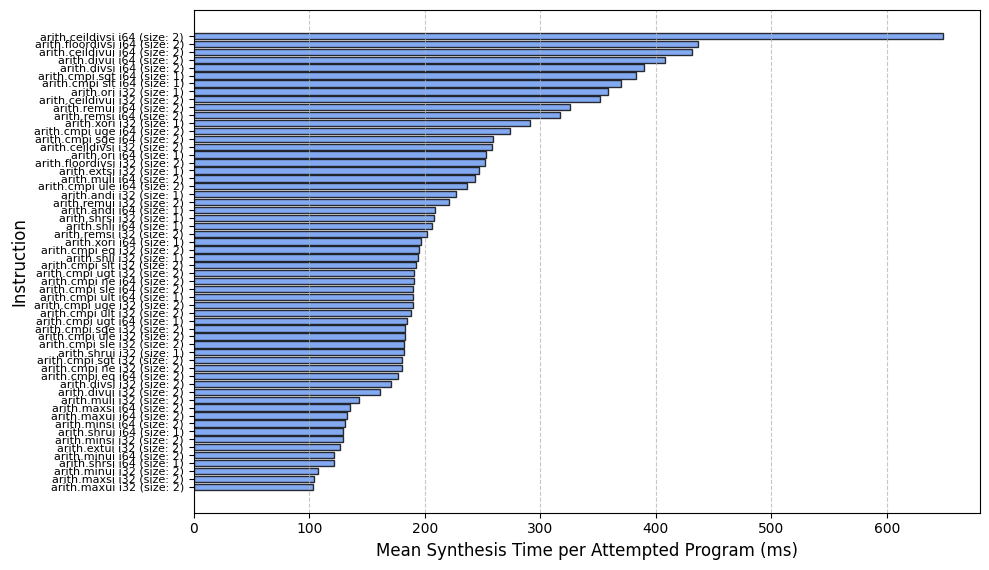

In [44]:
df = parse_synthesis_logs_all("arith_trunc_ref.jsonl")
plot_duration_per_program_bar(df)